In [ ]:
import numpy as np # handle numbers
import pandas as pd # handle data

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data # input features
y = data.target # output (0 {benign} or 1 {malignant})

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2) # 80% learning and 20% testing

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# making all values comparable (scaling)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained")
# uses sigmoid curve for categorical classification
# model learns patterns
# calculates probability and converts it into 0 or 1

Model trained


In [10]:
pred = model.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, pred))

0.9824561403508771


In [43]:
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train, y_train)
# svm finds best boundary between classes

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [44]:
svm.predict_proba(sample)

array([[0.09922677, 0.90077323]])

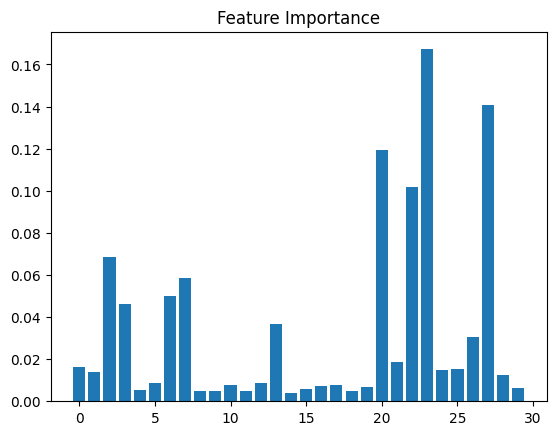

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
# use multiple small decision trees

import matplotlib.pyplot as plt

importances = rf.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()

In [14]:
lr_pred = model.predict(X_test)
svm_pred = svm.predict(X_test)
rf_pred = rf.predict(X_test)

In [30]:
results = pd.DataFrame({
    "Model": ["Logistic", "SVM", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print(results)

           Model  Accuracy
0       Logistic  0.982456
1            SVM  0.991228
2  Random Forest  0.982456


In [28]:
import joblib
joblib.dump(svm, "model.pkl")

['model.pkl']

In [17]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [18]:
print("Final model: SVM")

Final model: SVM


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [21]:
print("Accuracy:", accuracy_score(y_test, svm_pred)) # how many predictions were correct overall
print("Precision:", precision_score(y_test, svm_pred)) # out of predicted, how many were actual (to reduce false alarms)
print("Recall:", recall_score(y_test, svm_pred)) # out of actual, how many were detected correctly (to not miss cases)
print("F1 Score:", f1_score(y_test, svm_pred)) # balance between precision and recall

Accuracy: 0.9912280701754386
Precision: 1.0
Recall: 0.9857142857142858
F1 Score: 0.9928057553956835


In [22]:
from sklearn.metrics import confusion_matrix

In [25]:
confusion_matrix(y_test, svm_pred)
# a11 = actual benign and predicted benign
# a12 = actual benign and predicted malignant
# a21 = actual malignant and predicted benign
# a22 = actual malignant and predicted malignant

array([[44,  0],
       [ 1, 69]])

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        44
           1       1.00      0.99      0.99        70

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



In [32]:
sample = X_test[0].reshape(1, -1)
print("Prediction:", svm.predict(sample))
print("Actual:", y_test[0])

Prediction: [1]
Actual: 1
